# Questions Q1-Q3

This notebook answers the first three cross-cutting questions from the plan using the aggregated phase outputs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from analysis_helpers import (
    ALGORITHM_ORDER,
    ALGORITHM_PALETTE,
    contamination_stratum,
    load_descriptive_stats,
    load_phase4_summary,
    save_figure,
    setup_theme,
)

setup_theme()
summary = load_phase4_summary()
descriptive = load_descriptive_stats().rename(columns={"dataset_id": "dataset"})
frame = summary.merge(
    descriptive[
        [
            "dataset",
            "contamination",
            "n_features",
            "n_rows",
            "mean_abs_correlation",
            "distance_concentration_ratio",
        ]
    ],
    on="dataset",
    how="left",
)
frame["contamination_band"] = frame["contamination"].apply(contamination_stratum)
frame.head()

,run_name,dataset,algorithm,variant,seed,pr_auc,roc_auc,mcc,f1,distance_concentration_ratio_x,n_features_x,pca_variance,recall_type_g,recall_type_l,contamination,n_features_y,n_rows,mean_abs_correlation,distance_concentration_ratio_y,contamination_band
0,phase4__thyroid__IForest__seed-42__task-003314...,thyroid,IForest,bootstrap-iforest-stable,42,0.669421,0.983536,0.650914,0.659574,45.091528,6.0,NaN,NaN,NaN,0.024655,6,3772,0.262441,3.097113,low (2-10%)
1,phase4__pima__OCSVM__seed-42__task-003313__cfg...,pima,OCSVM,lhs-ocsvm-pima,42,0.492475,0.655724,0.246981,0.510242,2.615846,8.0,NaN,NaN,NaN,0.348958,8,768,0.171657,5.706843,high (>=30%)
2,phase4__ionosphere__OCSVM__seed-42__task-00331...,ionosphere,OCSVM,lhs-ocsvm-ionosphere,42,0.902870,0.906279,0.721928,0.822134,2.314527,32.0,NaN,NaN,NaN,0.358974,32,351,0.238266,1.964553,high (>=30%)
3,phase4__breastw__OCSVM__seed-42__task-003311__...,breastw,OCSVM,lhs-ocsvm-breastw,42,0.933811,0.978872,0.868187,0.914405,3.638783,9.0,NaN,NaN,NaN,0.349927,9,683,0.601939,2.280981,high (>=30%)
4,phase4__pima__OCSVM__seed-42__task-003310__cfg...,pima,OCSVM,sobol-ocsvm-pima,42,0.492005,0.655522,0.235528,0.502793,2.615846,8.0,NaN,NaN,NaN,0.348958,8,768,0.171657,5.706843,high (>=30%)


,family,contamination_band,std_pr_auc
0,prior-dependent,high (>=30%),0.215027
1,prior-dependent,low (2-10%),0.244372
2,prior-dependent,mid (10-30%),0.278246
3,prior-dependent,sparse (<2%),0.281573
4,prior-free,high (>=30%),0.232333
5,prior-free,low (2-10%),0.282600
6,prior-free,mid (10-30%),0.200253
7,prior-free,sparse (<2%),0.194681


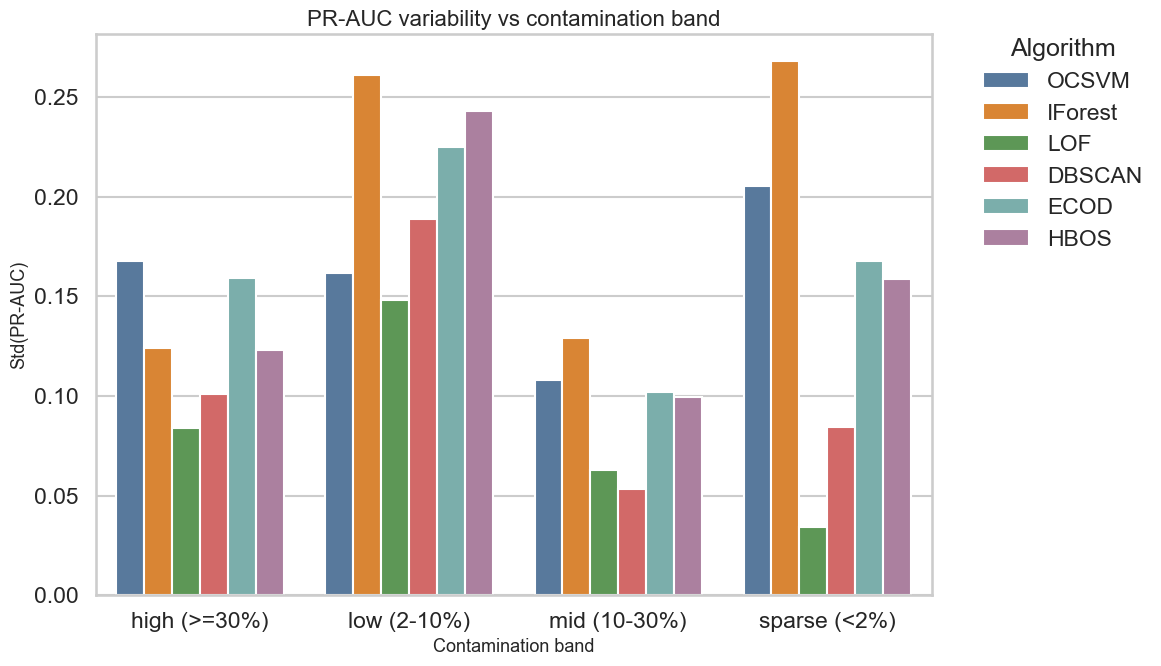

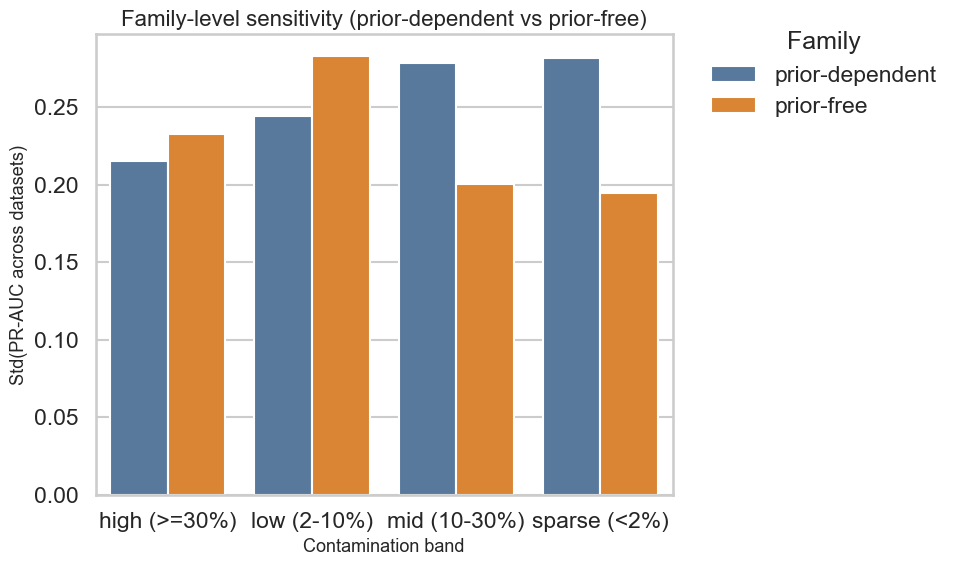

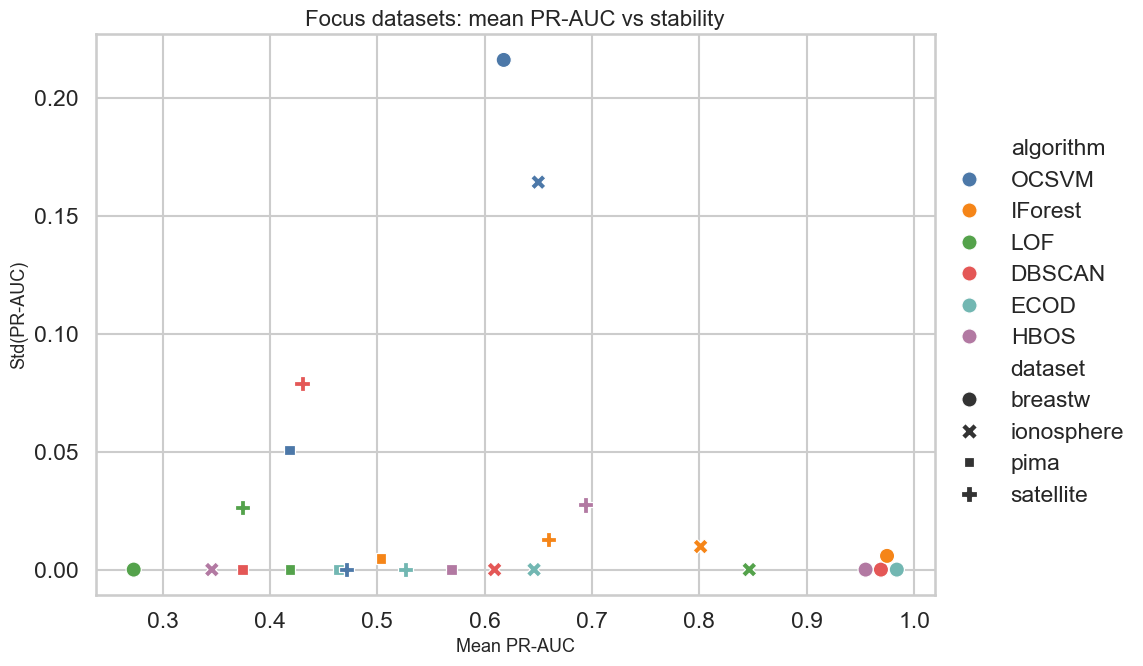

In [2]:
q1 = (
    frame.groupby(["algorithm", "contamination_band"], as_index=False)["pr_auc"]
    .agg(["mean", "std"])
    .reset_index()
)
q1 = q1.rename(columns={"mean": "pr_auc_mean", "std": "pr_auc_std"})

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=q1,
    x="contamination_band",
    y="pr_auc_std",
    hue="algorithm",
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    ax=ax,
)
ax.set_title("PR-AUC variability vs contamination band")
ax.set_xlabel("Contamination band")
ax.set_ylabel("Std(PR-AUC)")
plt.legend(title="Algorithm", loc=(1.05, 0.6))
plt.tight_layout()
# annotate_figure(
#     fig, "Std computed from all phase4 runs grouped by algorithm and contamination band."
# )
save_figure("q1_pr_auc_std_by_contamination_band.png")

family_map = {
    "OCSVM": "prior-dependent",
    "IForest": "prior-dependent",
    "ECOD": "prior-free",
    "HBOS": "prior-free",
}
q1_family = frame[frame["algorithm"].isin(family_map)].assign(
    family=lambda d: d["algorithm"].map(family_map)
)
q1_family = (
    q1_family.groupby(["family", "contamination_band", "dataset"], as_index=False)["pr_auc"]
    .median()
    .groupby(["family", "contamination_band"], as_index=False)["pr_auc"]
    .std()
    .rename(columns={"pr_auc": "std_pr_auc"})
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=q1_family, x="contamination_band", y="std_pr_auc", hue="family", ax=ax)
ax.set_title("Family-level sensitivity (prior-dependent vs prior-free)")
ax.set_xlabel("Contamination band")
ax.set_ylabel("Std(PR-AUC across datasets)")
plt.legend(title="Family", loc=(1.05, 0.8))
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Family sensitivity: dataset-level median PR-AUC then std across "
#      "datasets within each contamination band."),
# )
save_figure("q1_family_sensitivity.png")

focus_datasets = ["breastw", "ionosphere", "pima", "satellite"]
focus = frame[frame["dataset"].isin(focus_datasets)].copy()
focus_plot = (
    focus.groupby(["dataset", "algorithm"], as_index=False)["pr_auc"]
    .agg(["mean", "std"])
    .reset_index()
)
focus_plot = focus_plot.rename(columns={"mean": "pr_auc_mean", "std": "pr_auc_std"})

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=focus_plot,
    x="pr_auc_mean",
    y="pr_auc_std",
    hue="algorithm",
    style="dataset",
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    s=120,
    ax=ax,
)
ax.set_title("Focus datasets: mean PR-AUC vs stability")
ax.set_xlabel("Mean PR-AUC")
ax.set_ylabel("Std(PR-AUC)")
plt.legend(bbox_to_anchor=(1.25, 0.85))
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Focus datasets only; each point shows mean and std of PR-AUC across "
#      "all runs/seeds for one algorithm."),
# )
save_figure("q1_focus_datasets_mean_vs_stability.png")

q1_family

,algorithm,slope_log_n_features
0,DBSCAN,0.074991
4,LOF,0.085989
5,OCSVM,0.097994
1,ECOD,0.117151
3,IForest,0.129366
2,HBOS,0.132277


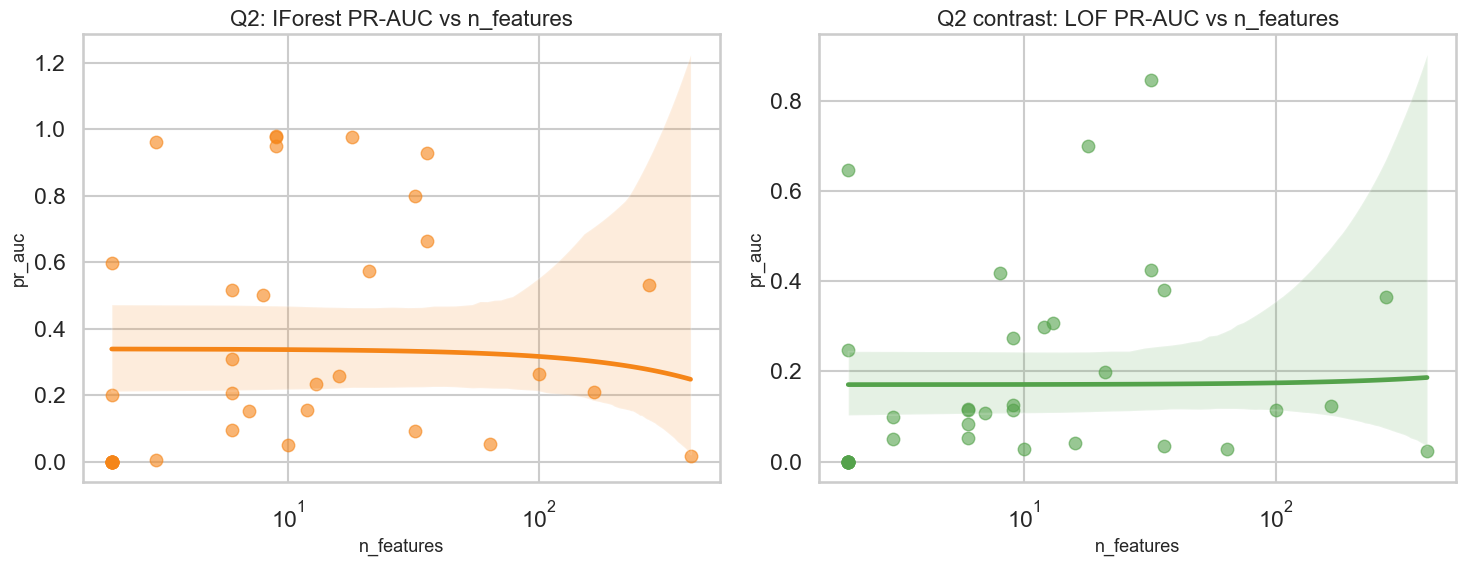

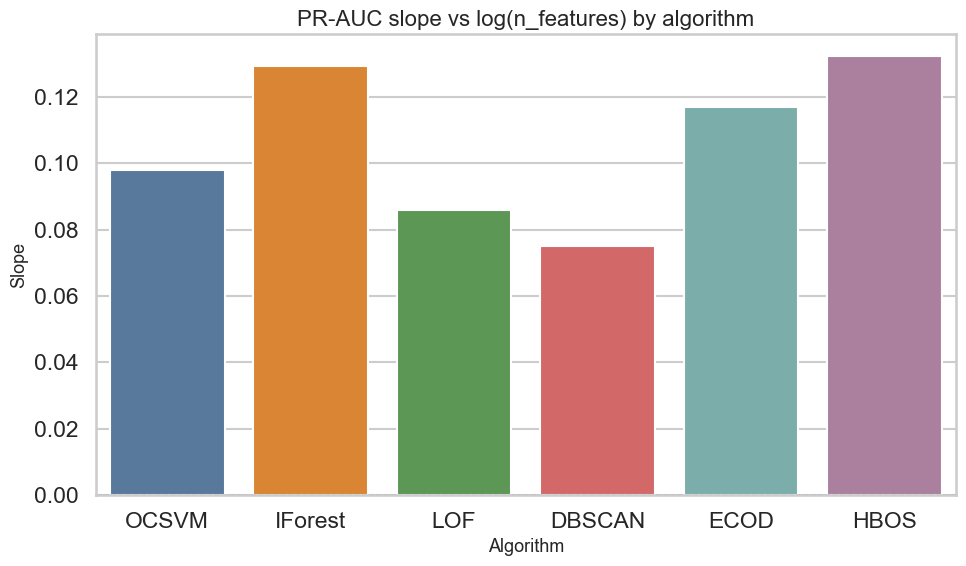

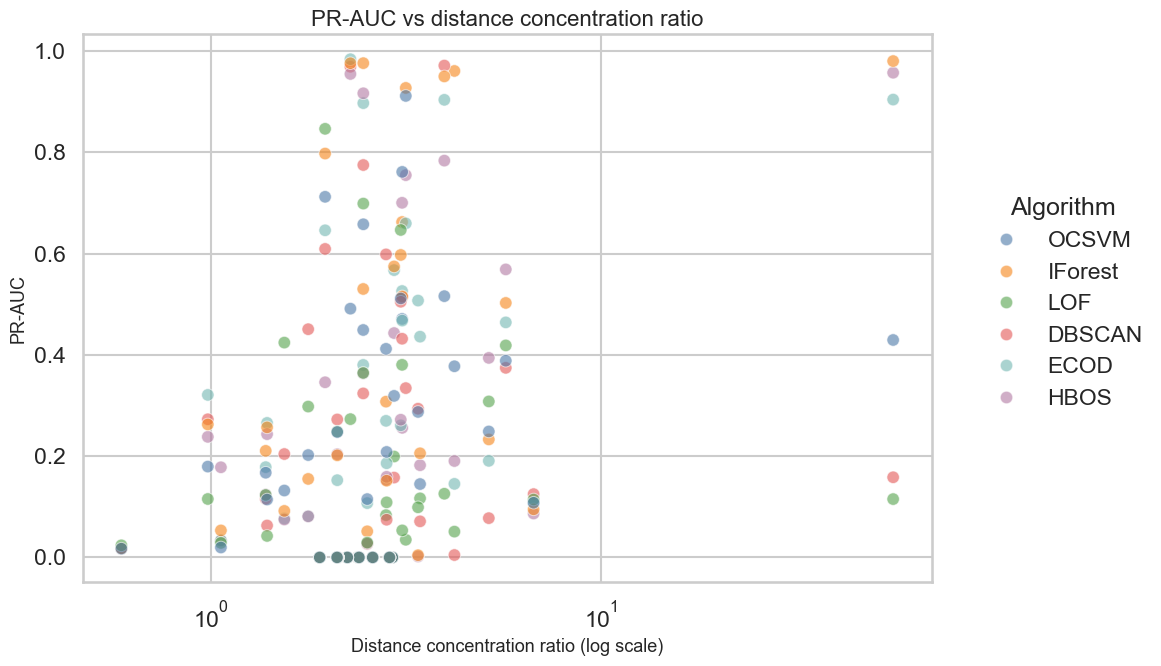

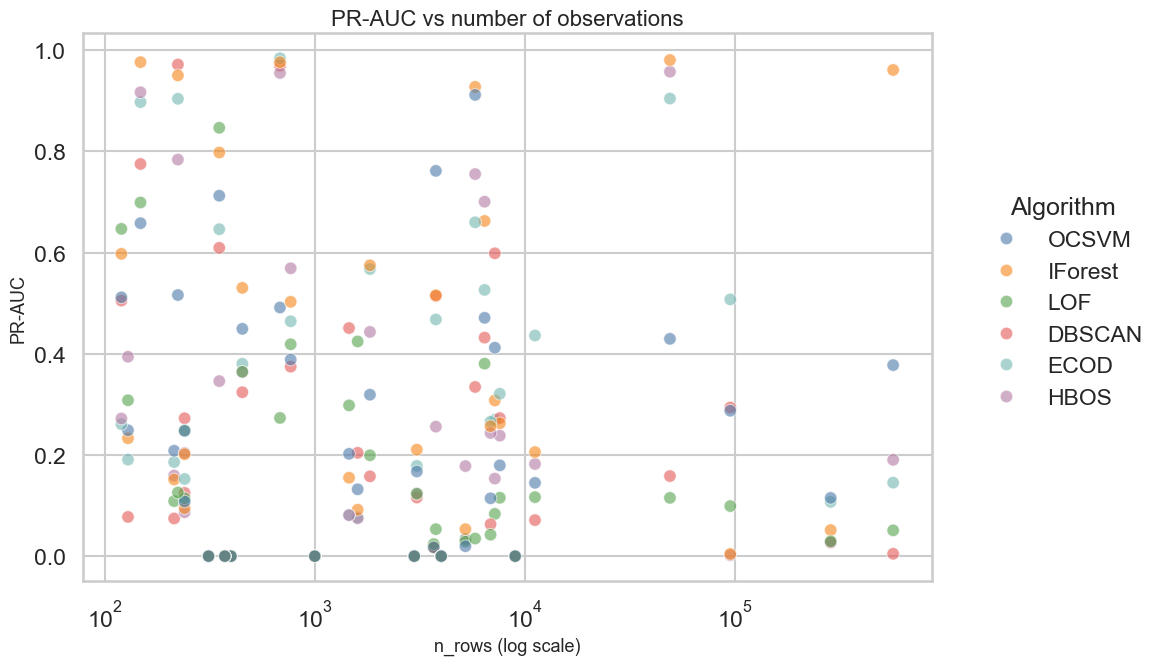

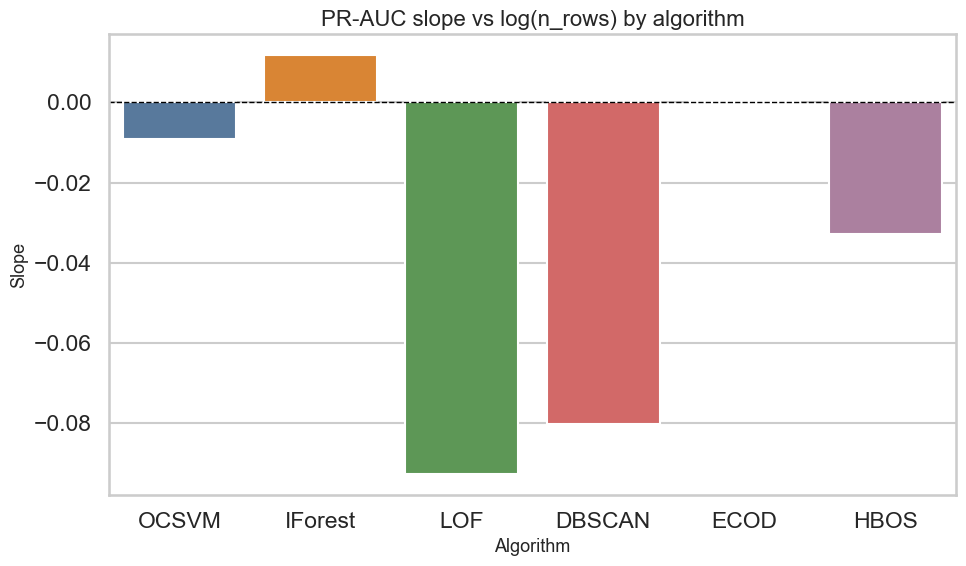

In [3]:
q2 = frame.groupby(["dataset", "algorithm"], as_index=False)["pr_auc"].median()
q2 = q2.merge(
    descriptive[["dataset", "n_features", "n_rows", "distance_concentration_ratio"]],
    on="dataset",
    how="left",
)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.regplot(
    data=q2[q2["algorithm"] == "IForest"],
    x="n_features",
    y="pr_auc",
    scatter_kws={"alpha": 0.6},
    ax=axes[0],
    color=ALGORITHM_PALETTE["IForest"],
)
axes[0].set_xscale("log")
axes[0].set_title("Q2: IForest PR-AUC vs n_features")
sns.regplot(
    data=q2[q2["algorithm"] == "LOF"],
    x="n_features",
    y="pr_auc",
    scatter_kws={"alpha": 0.6},
    ax=axes[1],
    color=ALGORITHM_PALETTE["LOF"],
)
axes[1].set_xscale("log")
axes[1].set_title("Q2 contrast: LOF PR-AUC vs n_features")
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Per dataset+algorithm median PR-AUC over all runs; regression "
#      "contrasts IForest vs LOF against n_features."),
# )
save_figure("q2_iforest_vs_lof_dimensionality.png")
slope_rows: list[dict[str, float | str]] = []
for algorithm, g in q2.groupby("algorithm"):
    gg = g.dropna(subset=["n_features", "pr_auc"])
    if len(gg) < 3:
        continue
    x = np.log10(gg["n_features"].to_numpy())
    y = gg["pr_auc"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    slope_rows.append({"algorithm": algorithm, "slope_log_n_features": float(slope)})
slope_table = pd.DataFrame(slope_rows).sort_values("slope_log_n_features")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=slope_table,
    x="algorithm",
    y="slope_log_n_features",
    hue="algorithm",
    order=ALGORITHM_ORDER,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    legend=False,
    ax=ax,
)
ax.axhline(0.0, linestyle="--", color="black", linewidth=1)
ax.set_title("PR-AUC slope vs log(n_features) by algorithm")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Slope")
plt.tight_layout()
# annotate_figure(
#     fig, "Slope estimated from log(n_features) vs median PR-AUC per dataset for each algorithm."
# )
save_figure("q2_slope_by_algorithm.png")
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=q2,
    x="distance_concentration_ratio",
    y="pr_auc",
    hue="algorithm",
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    alpha=0.6,
    ax=ax,
)
sns.move_legend(ax, "upper right", ncol=2)
ax.set_xscale("log")
ax.set_title("PR-AUC vs distance concentration ratio")
ax.set_xlabel("Distance concentration ratio (log scale)")
ax.set_ylabel("PR-AUC")
plt.legend(title="Algorithm", loc=(1.05, 0.3))
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Scatter uses per dataset+algorithm median PR-AUC; distance "
#      "concentration from descriptive stats."),
# )
save_figure("q2_pr_auc_vs_distance_concentration.png")
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=q2,
    x="n_rows",
    y="pr_auc",
    hue="algorithm",
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    alpha=0.6,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("PR-AUC vs number of observations")
ax.set_xlabel("n_rows (log scale)")
ax.set_ylabel("PR-AUC")
plt.legend(title="Algorithm", loc=(1.05, 0.3))
plt.tight_layout()
save_figure("q2_pr_auc_vs_log_n_rows.png")
size_slope_rows: list[dict[str, float | str]] = []
for algorithm, g in q2.groupby("algorithm"):
    gg = g.dropna(subset=["n_rows", "pr_auc"])
    if len(gg) < 3:
        continue
    x = np.log10(gg["n_rows"].to_numpy())
    y = gg["pr_auc"].to_numpy()
    slope, _ = np.polyfit(x, y, 1)
    size_slope_rows.append({"algorithm": algorithm, "slope_log_n_rows": float(slope)})
size_slope_table = pd.DataFrame(size_slope_rows).sort_values("slope_log_n_rows")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=size_slope_table,
    x="algorithm",
    y="slope_log_n_rows",
    hue="algorithm",
    order=ALGORITHM_ORDER,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    legend=False,
    ax=ax,
)
ax.axhline(0.0, linestyle="--", color="black", linewidth=1)
ax.set_title("PR-AUC slope vs log(n_rows) by algorithm")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Slope")
plt.tight_layout()
save_figure("q2_slope_vs_log_n_rows_by_algorithm.png")
slope_table

,dataset,mean_abs_correlation,abs_gap_ecod_lof
20,shuttle,0.178746,0.789078
30,wbc,0.419352,0.778028
2,breastw,0.601939,0.710815
19,satimage-2,0.637425,0.624856
27,thyroid,0.262441,0.414441
25,smtp,0.265015,0.408332
36,wut/x2,0.504044,0.385907
3,cardio,0.220603,0.368145
10,letter,0.201692,0.347568
12,mammography,0.243973,0.319344


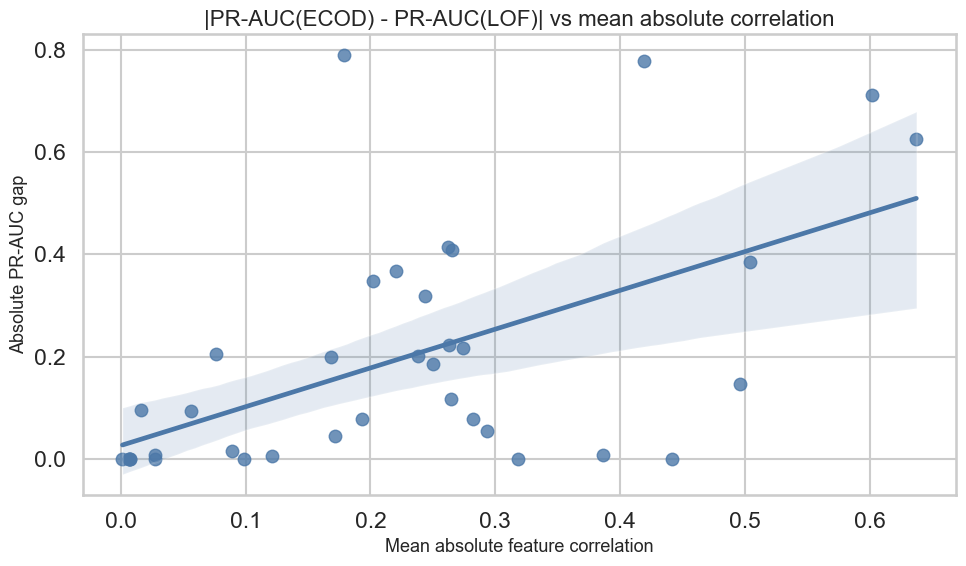

In [4]:
ecod_lof = (
    frame.groupby(["dataset", "algorithm"], as_index=False)["pr_auc"]
    .median()
    .pivot(index="dataset", columns="algorithm", values="pr_auc")
    .reset_index()
    .merge(descriptive[["dataset", "mean_abs_correlation"]], on="dataset", how="left")
)
ecod_lof["abs_gap_ecod_lof"] = (ecod_lof["ECOD"] - ecod_lof["LOF"]).abs()

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=ecod_lof, x="mean_abs_correlation", y="abs_gap_ecod_lof", ax=ax)
ax.set_title("|PR-AUC(ECOD) - PR-AUC(LOF)| vs mean absolute correlation")
ax.set_xlabel("Mean absolute feature correlation")
ax.set_ylabel("Absolute PR-AUC gap")
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Each point = dataset; PR-AUC values are per-dataset medians over "
#      "all runs, regressed vs mean absolute correlation."),
# )
save_figure("q3_ecod_lof_gap_vs_correlation.png")

ecod_lof[["dataset", "mean_abs_correlation", "abs_gap_ecod_lof"]].sort_values(
    "abs_gap_ecod_lof", ascending=False
).head(10)

## Variance Decomposition

I split variability into two parts: differences between datasets and noise across seeds within the same dataset.

,algorithm,contamination_band,variance_source,std_component
15,IForest,sparse (<2%),between_dataset_std,0.334644
13,IForest,low (2-10%),between_dataset_std,0.313228
5,ECOD,low (2-10%),between_dataset_std,0.293326
14,IForest,mid (10-30%),between_dataset_std,0.288442
9,HBOS,low (2-10%),between_dataset_std,0.278793
1,DBSCAN,low (2-10%),between_dataset_std,0.278153
0,DBSCAN,high (>=30%),between_dataset_std,0.268380
23,OCSVM,sparse (<2%),between_dataset_std,0.256978
8,HBOS,high (>=30%),between_dataset_std,0.254025
22,OCSVM,mid (10-30%),between_dataset_std,0.253349


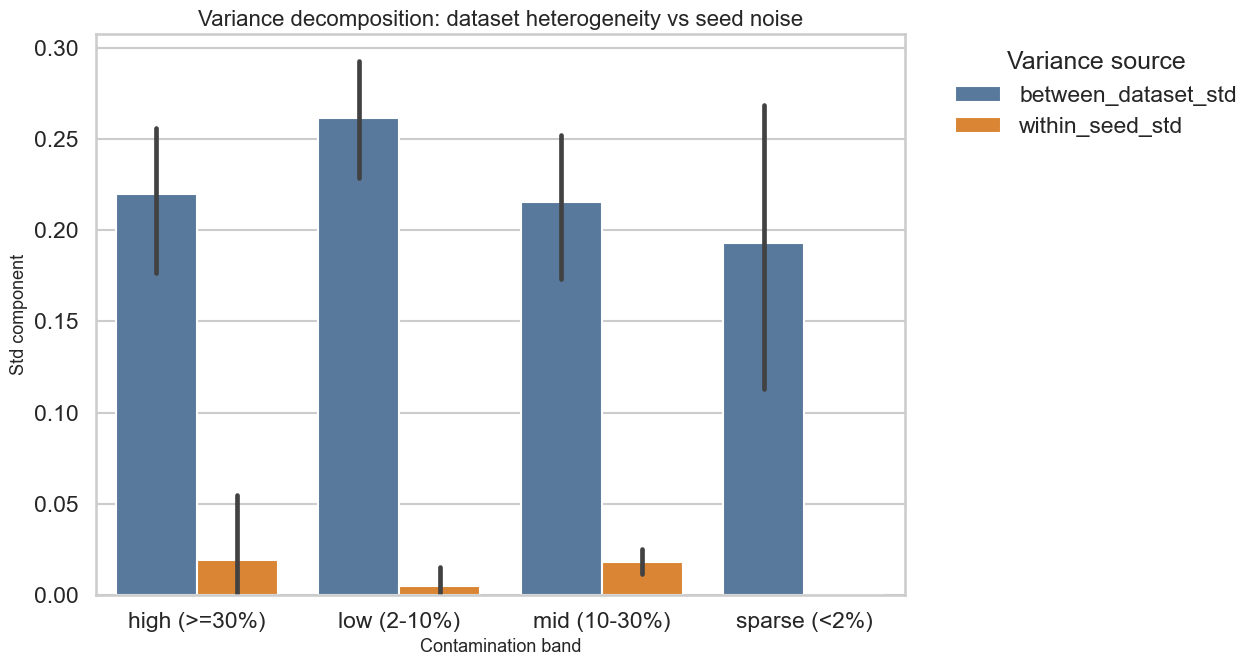

In [5]:
seed_level = (
    frame.groupby(["dataset", "algorithm", "contamination_band"], as_index=False)["pr_auc"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "dataset_mean", "std": "seed_std"})
)

between_dataset = (
    seed_level.groupby(["algorithm", "contamination_band"], as_index=False)["dataset_mean"]
    .std()
    .rename(columns={"dataset_mean": "between_dataset_std"})
)
within_seed = (
    seed_level.groupby(["algorithm", "contamination_band"], as_index=False)["seed_std"]
    .median()
    .rename(columns={"seed_std": "within_seed_std"})
)

decomp = between_dataset.merge(within_seed, on=["algorithm", "contamination_band"], how="outer")
long = decomp.melt(
    id_vars=["algorithm", "contamination_band"],
    value_vars=["between_dataset_std", "within_seed_std"],
    var_name="variance_source",
    value_name="std_component",
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(
    data=long,
    x="contamination_band",
    y="std_component",
    hue="variance_source",
    ax=ax,
)
ax.set_title("Variance decomposition: dataset heterogeneity vs seed noise")
ax.set_xlabel("Contamination band")
ax.set_ylabel("Std component")
plt.legend(title="Variance source", loc=(1.05, 0.8))
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Within-seed component from per dataset+algorithm seed std; "
#      "between-dataset from std of dataset means."),
# )
save_figure("q1_variance_decomposition.png")

long.sort_values("std_component", ascending=False).head(20)

/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_40186/3722884130.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Global/point-dominant", "Local/cluster-dominant"])


,index,outlier_regime,algorithm,pr_auc_mean,pr_auc_std,n_dataset
0,0,global_point,DBSCAN,0.250153,0.223758,8
1,1,global_point,ECOD,0.437150,0.266108,8
2,2,global_point,HBOS,0.315410,0.348427,8
3,3,global_point,IForest,0.494119,0.413365,8
4,4,global_point,LOF,0.072831,0.035286,8
5,5,global_point,OCSVM,0.429900,0.279163,8
6,6,local_cluster,DBSCAN,0.335893,0.311129,18
7,7,local_cluster,ECOD,0.379253,0.314249,18
8,8,local_cluster,HBOS,0.370819,0.298729,18
9,9,local_cluster,IForest,0.416500,0.336560,18


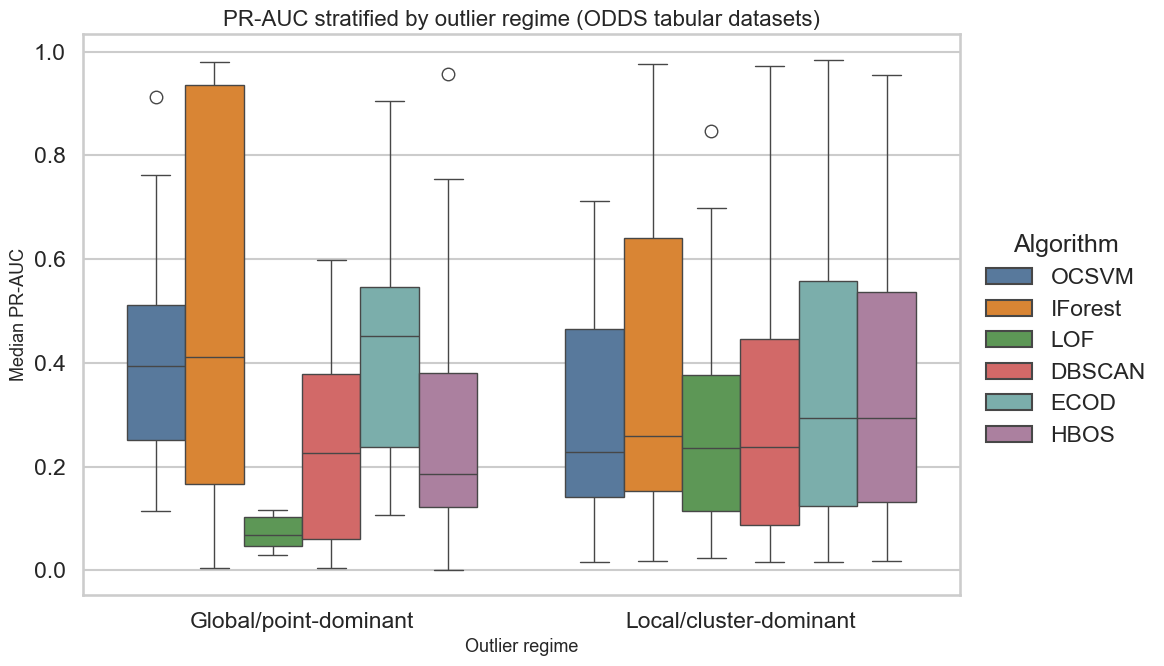

In [6]:
odds_datasets = {
    "annthyroid",
    "arrhythmia",
    "breastw",
    "cardio",
    "cover",
    "glass",
    "http",
    "ionosphere",
    "letter",
    "lympho",
    "mammography",
    "mnist",
    "musk",
    "optdigits",
    "pendigits",
    "pima",
    "satellite",
    "satimage-2",
    "shuttle",
    "smtp",
    "speech",
    "thyroid",
    "vertebral",
    "vowels",
    "wbc",
    "wine",
}
# Campos-style regime grouping for tabular ODDS benchmarks.
# local_cluster: anomalies embedded in cluster/neighborhood structure.
# global_point: anomalies mostly isolated from dominant mass.
outlier_regime = {
    "annthyroid": "global_point",
    "arrhythmia": "local_cluster",
    "breastw": "local_cluster",
    "cardio": "local_cluster",
    "cover": "global_point",
    "glass": "local_cluster",
    "http": "global_point",
    "ionosphere": "local_cluster",
    "letter": "local_cluster",
    "lympho": "local_cluster",
    "mammography": "global_point",
    "mnist": "local_cluster",
    "musk": "local_cluster",
    "optdigits": "local_cluster",
    "pendigits": "local_cluster",
    "pima": "local_cluster",
    "satellite": "local_cluster",
    "satimage-2": "global_point",
    "shuttle": "global_point",
    "smtp": "global_point",
    "speech": "local_cluster",
    "thyroid": "global_point",
    "vertebral": "local_cluster",
    "vowels": "local_cluster",
    "wbc": "local_cluster",
    "wine": "local_cluster",
}
q_local_global = (
    frame[frame["dataset"].isin(odds_datasets)]
    .groupby(["dataset", "algorithm"], as_index=False)["pr_auc"]
    .median()
)
q_local_global["outlier_regime"] = q_local_global["dataset"].map(outlier_regime)
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=q_local_global,
    x="outlier_regime",
    y="pr_auc",
    hue="algorithm",
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    ax=ax,
)
ax.set_title("PR-AUC stratified by outlier regime (ODDS tabular datasets)")
ax.set_xlabel("Outlier regime")
ax.set_ylabel("Median PR-AUC")
ax.set_xticklabels(["Global/point-dominant", "Local/cluster-dominant"])
plt.legend(title="Algorithm", loc=(1.02, 0.25))
plt.tight_layout()
save_figure("q4_pr_auc_by_outlier_regime.png")
regime_summary = (
    q_local_global.groupby(["outlier_regime", "algorithm"], as_index=False)["pr_auc"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "pr_auc_mean", "std": "pr_auc_std", "count": "n_dataset"})
)
regime_summary.to_csv("../outputs/local_global_taxonomy_summary.csv", index=False)
regime_summary.head(20)